In [1]:
import numpy as np
import torch
from analysis_functions import load_encoder, load_diffusion, forwardpass
from torch.utils.data import DataLoader
import os
from tqdm import tqdm
from matplotlib import pyplot as plt

In [2]:
from datasets.dataset import SimulationXZDataset
image_size = 80
channels = 1
batch_size =16
field_names = ['temperature']
device = 'cuda'
skip = 1
train_dataset = SimulationXZDataset(downscale_method = 'direct', split = 'train', root_folder = '/home/oogoke/DiffusionSR/datasets/expanded_ss316l_all_laser_velocity_xz_cross_section_data', return_info = True, field_names =  field_names, normalize = 'rescaling')
test_dataset = SimulationXZDataset(downscale_method ='direct', split = 'test', root_folder = '/home/oogoke/DiffusionSR/datasets/expanded_ss316l_all_laser_velocity_xz_cross_section_data', return_info = True, field_names =  field_names, normalize = 'rescaling')
dev_dataset = SimulationXZDataset(downscale_method = 'direct', split = 'dev', root_folder = '/home/oogoke/DiffusionSR/datasets/expanded_ss316l_all_laser_velocity_xz_cross_section_data', return_info = True, field_names =  field_names, normalize = 'rescaling')

dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
dev_dataloader = DataLoader(dev_dataset, batch_size=1, shuffle=False, drop_last=True)
test_dataloader = DataLoader(test_dataset, batch_size=1, shuffle=False, drop_last=True)

Using normalize method: ... rescaling
Using specific fields,  ['temperature']
Processing dataset with 1 fields
Using normalize method: ... rescaling
Using specific fields,  ['temperature']
Processing dataset with 1 fields
Using normalize method: ... rescaling
Using specific fields,  ['temperature']
Processing dataset with 1 fields


In [3]:
diffusion_results_dir = '/home/oogoke/DiffusionSR/runs/direct/diffusionimplicitencoded/2023_03_20_16_01_36/rescaling/n_steps_1'#'#'/home/oogoke/DiffusionSR/runs/direct/diffusionimplicitencoded/2023_03_19_22_56_20/standardize/n_steps_1'#'/home/oogoke/DiffusionSR/runs/direct/diffusionimplicitencoded/2023_03_17_03_43_34/rescaling/n_steps_1'
encoder_results_dir = '/home/oogoke/DiffusionSR/runs/direct/encoder/2023_03_20_16_01_36/rescaling/n_steps_1'#'/home/oogoke/DiffusionSR/runs/direct/encoder/2023_03_20_16_11_43/standardize/n_steps_1'#'/home/oogoke/DiffusionSR/runs/direct/encoder/2023_03_19_22_56_20/standardize/n_steps_1'#'/home/oogoke/DiffusionSR/runs/direct/encoder/2023_03_17_03_43_34/rescaling/n_steps_1'
mobilenet_results_dir = '/home/oogoke/DiffusionSR/runs/clean/direct/mobilenet/2022_12_05_03_17_09'

In [19]:
from models.diffusion_model import Unet
from models.lr_encoder_model import rrdbnet_encoder as rrdbnet_x4
os.environ['CUDA_VISIBLE_DEVICES']  = "5"
device = 'cuda'
criterion = torch.nn.L1Loss()
multi_field_results_dir = 'expanded_results'
lr_enc = load_encoder(encoder_results_dir, dataset = train_dataset)
model = load_diffusion(diffusion_results_dir, dataset = train_dataset)
batch_size = 2
dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)



In [20]:
res, hr, lr, upscaled_lr, info = iter(dataloader).next()

In [6]:
schedule = 'linear'
timesteps = 1000


In [7]:

# skip =timesteps // self.args.timesteps
seq = range(0, timesteps, skip)


def compute_alpha(beta, t):
    beta = torch.cat([torch.zeros(1).to(beta.device), beta], dim=0).to(device)
    # print(beta.device, t.device)
    a = (1 - beta).cumprod(dim=0).index_select(0, t + 1).view(-1, 1, 1, 1)
    return a
def cosine_beta_schedule(timesteps, s=0.008):

    steps = timesteps + 1
    x = torch.linspace(0, timesteps, steps)
    alphas_cumprod = torch.cos(
        ((x / timesteps) + s) / (1 + s) * torch.pi * 0.5) ** 2
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    return torch.clip(betas, 0.0001, 0.9999)

def linear_beta_schedule(timesteps):
    beta_start = 0.0001
    beta_end = 0.02
    return torch.linspace(beta_start, beta_end, timesteps)


def quadratic_beta_schedule(timesteps):
    beta_start = 0.0001
    beta_end = 0.02
    return torch.linspace(beta_start**0.5, beta_end**0.5, timesteps) ** 2

def sigmoid_beta_schedule(timesteps):
    beta_start = 0.0001
    beta_end = 0.02
    betas = torch.linspace(-6, 6, timesteps)
    return torch.sigmoid(betas) * (beta_end - beta_start) + beta_start
if schedule == 'linear':
    bs = linear_beta_schedule(timesteps=timesteps)
elif schedule == 'quadratic':
    bs = quadratic_beta_schedule(timesteps=timesteps)
elif schedule == 'cosine':
    bs = cosine_beta_schedule(timesteps=timesteps)
elif schedule == 'sigmoid':
    bs = sigmoid_beta_schedule(timesteps=timesteps)
else:
    raise Exception('schedule must be defined')


if len(lr.shape) < 4:
    img = (lr.view(lr.shape[0], 1, lr.shape[1], lr.shape[2]).to(device))
    target = (hr.view(hr.shape[0], 1, hr.shape[1], hr.shape[2]).to(device))
else:
    img = lr.to(device)
    target = hr.to(device)
if len(lr.shape)< 4:

    x_e = forwardpass(lr_enc, lr.view(lr.shape[0],1, lr.shape[1], lr.shape[2]).to(device).float(), factor = train_dataset.factor)
else:
    x_e = forwardpass(lr_enc, lr.to(device).float(), factor = train_dataset.factor)


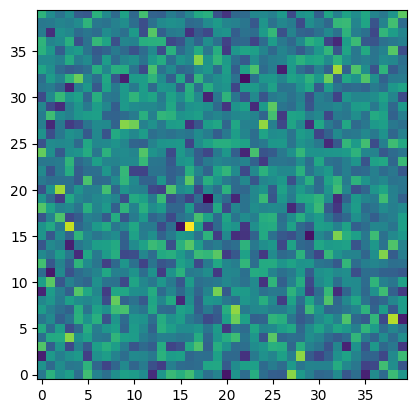

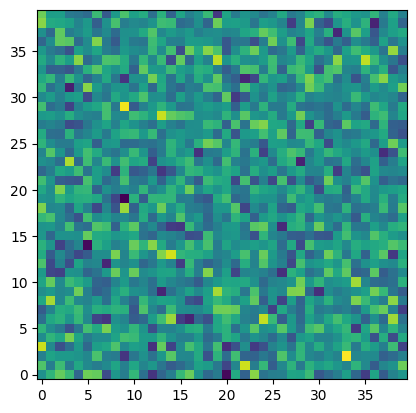

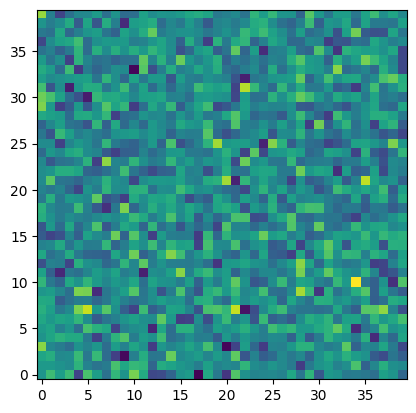

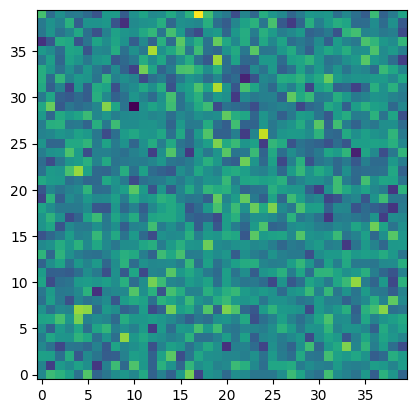

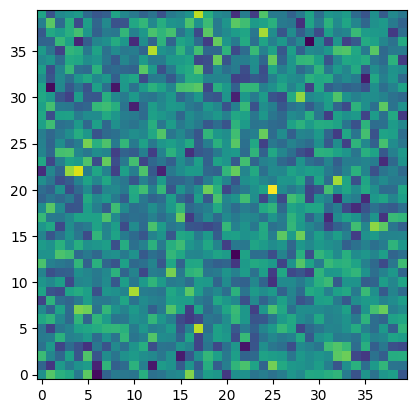

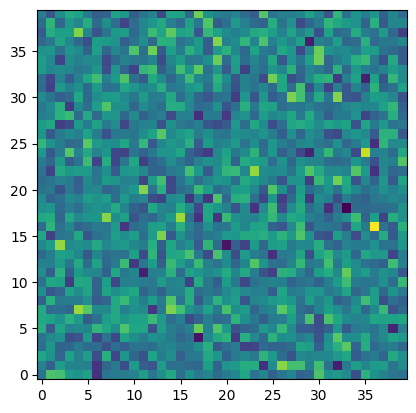

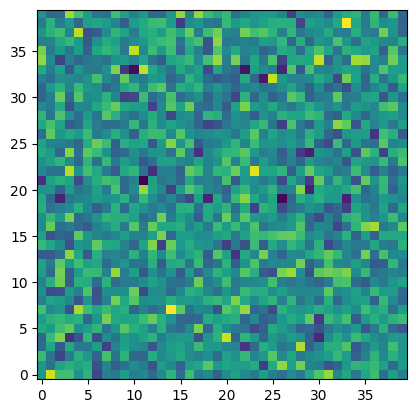

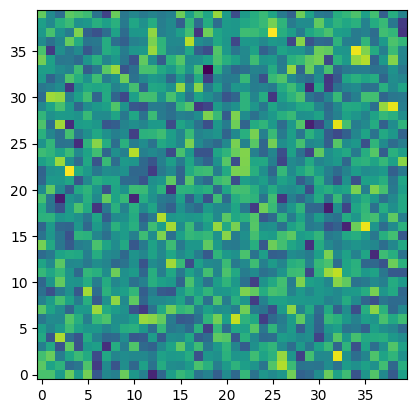

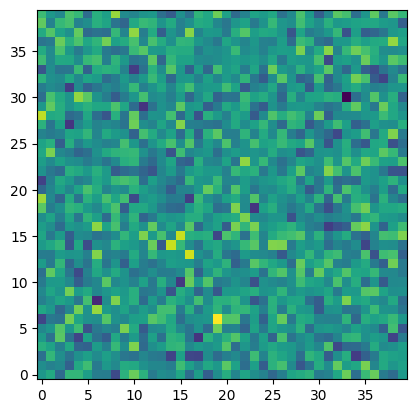

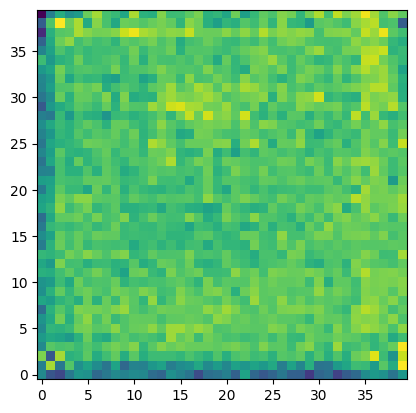

In [23]:
# DDPM ADAPTED FROM
shape=hr.shape
with torch.no_grad():
    x = torch.randn(shape, device=device)
    n = x.size(0)
    seq_next = [-1] + list(seq[:-1])
    xs = [x]
    x0_preds = []
    
    for i, j in zip(reversed(seq), reversed(seq_next)):

        noise = torch.randn_like(x)

        t = (torch.ones(n) * i).to(x.device)
        next_t = (torch.ones(n) * j).to(x.device)
        at = compute_alpha(bs, t.long())
        atm1 = compute_alpha(bs, next_t.long())
        beta_t = 1 - at / atm1
        x = xs[-1].to('cuda')

        et =model(x, t, x_e)
        x0_from_e = (1.0 / at).sqrt() * x - (1.0 / at - 1).sqrt() * et
        x0_preds.append(x0_from_e.to('cpu'))
        mean_eps = (
            (atm1.sqrt() * beta_t) * x0_from_e + ((1 - beta_t).sqrt() * (1 - atm1)) * x
        ) / (1.0 - at)

        mean = mean_eps
        mask = 1 - (t == 0).float()
        mask = mask.view(-1, 1, 1, 1)
        logvar = beta_t.log()
        sample = mean + mask * torch.exp(0.5 * logvar) * noise
        xs.append(sample.to('cpu'))
        if i %100 == 0:
            plt.imshow(sample[0][0].cpu().T, origin = 'lower')
            plt.show()
plt.close('all')


In [24]:
# ORIGINAL DDPM

from torch import nn
def extract(a, t, x_shape):
    batch_size = t.shape[0]
    out = a.gather(-1, t.cpu())
    return out.reshape(batch_size, *((1,) * (len(x_shape) - 1))).to(t.device)

betas = linear_beta_schedule(timesteps=timesteps)

# define alphas
alphas = 1. - betas
alphas_cumprod = torch.cumprod(alphas, axis=0)
alphas_cumprod_prev = nn.functional.pad(alphas_cumprod[:-1], (1, 0), value=1.0)
sqrt_recip_alphas = torch.sqrt(1.0 / alphas)

# calculations for diffusion q(x_t | x_{t-1}) and others
sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - alphas_cumprod)

# calculations for posterior q(x_{t-1} | x_t, x_0)
posterior_variance = betas * \
    (1. - alphas_cumprod_prev) / (1. - alphas_cumprod)
@torch.no_grad()
def p_sample(model, x, x_e,  t, t_index):
    betas_t = extract(betas, t, x.shape)
    sqrt_one_minus_alphas_cumprod_t = extract(
        sqrt_one_minus_alphas_cumprod, t, x.shape
    )
    sqrt_recip_alphas_t = extract(sqrt_recip_alphas, t, x.shape)

    # Equation 11 in the paper
    # Use our model (noise predictor) to predict the mean
    model_mean = sqrt_recip_alphas_t * (
        x - betas_t * model(x, t, x_e) / sqrt_one_minus_alphas_cumprod_t
    )

    if t_index == 0:
        return model_mean
    else:
        posterior_variance_t = extract(posterior_variance, t, x.shape)
        noise = torch.randn_like(x)
        # Algorithm 2 line 4:
        return model_mean + torch.sqrt(posterior_variance_t) * noise


device = next(model.parameters()).device

b = shape[0]
# start from pure noise (for each example in the batch)
img = torch.randn(shape, device=device)
imgs = []

for i in tqdm(reversed(range(0, timesteps)), desc='sampling loop time step', total=timesteps):
    # print(i)
    
    img = p_sample(model, img, x_e,  torch.full(
        (b,), i, device=device, dtype=torch.long), i)
    imgs.append(img.cpu())


sampling loop time step: 100%|██████████| 1000/1000 [00:10<00:00, 91.65it/s]


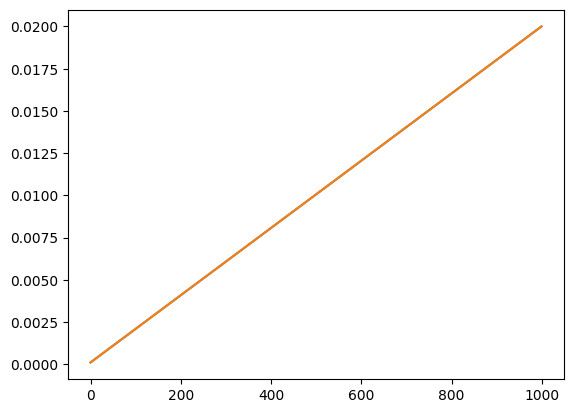

In [27]:
plt.plot(betas)
plt.plot(b)

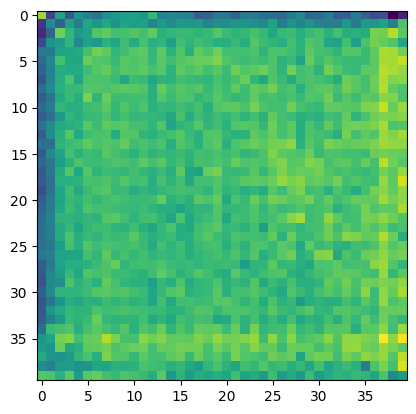

In [26]:
# plt.imshow(imgs[-1][

In [29]:
atm1

tensor([[[[1.]]],


        [[[1.]]]], device='cuda:0')

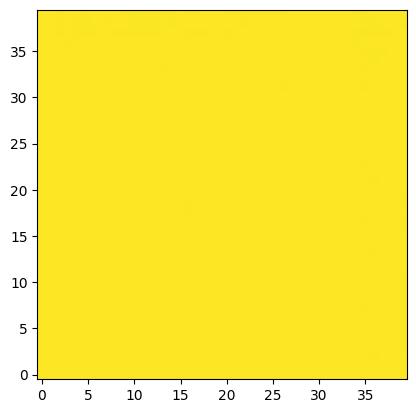

In [15]:
plt.imshow(293+(293-5000)*imgs[-1][0,0].cpu().numpy().T, origin = 'lower', vmin = 293, vmax = 5000)

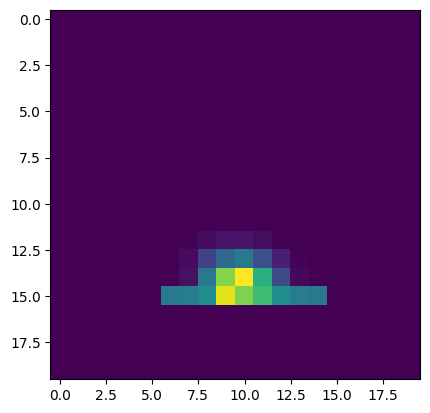

In [21]:
plt.imshow(lr[0][0].T.cpu().numpy())